# Baselines and probabilistic evaluation

**Question.** What do the fixed HGB80/HGB100 baselines achieve under the same chronological tuning and calibration opportunities?

Both baselines use the model inputs established in Notebook 02, two L2 candidates and the same candidate calibration families. The HGB fitting, calibration and evaluation procedures are defined below. A completed compatible run reuses its frozen predictions; a raw-only run fits baselines here, before the proposed-model experiment in Notebook 05. Supporting psychometric results use a separate fixed-split design and are not mixed into the monthly comparison.

In [1]:
from pathlib import Path
import sys, types, hashlib, importlib.abc, importlib.util
import nbformat
import pandas as pd
from IPython.core.magic import register_cell_magic
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Notebooks').is_dir() and (p/'Data').is_dir())
for area in ['Data','Models','Tables','Figures']:
    (ROOT/area/'Round2').mkdir(parents=True,exist_ok=True)
(ROOT/'Tables/Round2/manifests').mkdir(parents=True,exist_ok=True)
MODULE_NOTEBOOKS={'round2_analysis': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_data': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_models': ['03_baseline_models_and_error_diagnostics.ipynb', '05_proposed_model_development_and_ablations.ipynb'], 'revision_sensitivity': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_neural': '04_modern_models_and_comparative_diagnostics.ipynb', 'revision_evaluation': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_supplemental': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_provenance': '05_proposed_model_development_and_ablations.ipynb', 'revision_validation': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_closure': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_status': '06_frozen_evaluation_statistics_and_publication_results.ipynb'}

class NotebookSourceLoader(importlib.abc.Loader):
    def create_module(self,spec):return None
    def exec_module(self,module):
        names=MODULE_NOTEBOOKS[module.__name__]
        names=[names] if isinstance(names,str) else names
        cells=[]
        for name in names:
            notebook=nbformat.read(ROOT/'Notebooks'/name,4)
            cells.extend(c for c in notebook.cells if c.metadata.get('research_module')==module.__name__)
        cells.sort(key=lambda c:c.metadata.get('module_order',0))
        source=''.join(c.source.split('\n',1)[1] for c in cells)
        path=ROOT/'Notebooks'/names[-1]
        module.__file__=str(path)
        module.__notebook_source__=source
        module.__notebook_source_sha256__=hashlib.sha256(source.encode()).hexdigest()
        exec(compile(source,str(path)+'#'+module.__name__,'exec'),module.__dict__)

class NotebookSourceFinder(importlib.abc.MetaPathFinder):
    def find_spec(self,fullname,path=None,target=None):
        if fullname in MODULE_NOTEBOOKS:
            return importlib.util.spec_from_loader(fullname,NotebookSourceLoader())
sys.meta_path=[f for f in sys.meta_path if type(f).__name__!='NotebookSourceFinder']
sys.meta_path.insert(0,NotebookSourceFinder())

@register_cell_magic
def research_module(line, source):
    """Load the visible definition cells as one module, without external Python files."""
    import importlib
    importlib.import_module(line.strip())

if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import revision_data as rd
artifact_path=rd.artifact_path
import matplotlib as mpl
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
mpl.rcParams.update({'figure.dpi':350,'savefig.dpi':350})
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.text import Text
from IPython.display import HTML, Image, Markdown
from IPython.utils.capture import capture_output

font_path = font_manager.findfont("Times New Roman", fallback_to_default=False)
mpl.rcParams.update({
    "font.family": "Times New Roman", "font.size": 18,
    "axes.titlesize": 20, "axes.labelsize": 18,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "legend.fontsize": 18, "figure.titlesize": 20,
    "figure.dpi": 350, "savefig.dpi": 350, "axes.unicode_minus": True,
})
pd.set_option("display.max_colwidth", None)

def show_table(frame, title, identifiers=(), width=5, rows=18):
    """Render every scientific row and column in compact, untruncated parts."""
    frame = frame.reset_index(drop=True)
    identifiers = [c for c in identifiers if c in frame]
    values = [c for c in frame if c not in identifiers]
    groups = [values[i:i + width] for i in range(0, len(values), width)] or [[]]
    display(Markdown("**" + title + "**"))
    for start in range(0, max(1, len(frame)), rows):
        for group in groups:
            part = frame.iloc[start:start + rows][identifiers + group]
            def number(x):
                if abs(x) < 5e-12: return "0"
                return f"{x:.3e}" if abs(x) < 1e-4 else f"{x:.6f}".rstrip("0").rstrip(".")
            display(HTML(part.to_html(index=False, border=0, na_rep="Not available",
                                      float_format=number, max_rows=None, max_cols=None)))

def save_canvas(fig, stem):
    """Save and inspect the exact PNG/PDF; display a single PNG below the cell."""
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text().strip():
            assert 18 <= text.get_fontsize() <= 20
            assert Path(font_manager.findfont(text.get_fontproperties(),
                                             fallback_to_default=False)).name == Path(font_path).name
    png = artifact_path("Figures") / (stem + ".png")
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=350)
    fig.savefig(pdf, dpi=350)
    plt.close(fig)
    display(Image(filename=str(png), width=1050))

def load_frozen_predictions(models=None):
    """Check recorded file hashes before reading all seed/window predictions."""
    paths = sorted(artifact_path("Data").glob("round2_predictions_seed*_fold*.parquet"))
    assert len(paths) == 60
    for path in paths:
        suffix = path.stem.removeprefix("round2_predictions_")
        manifest = json.loads((artifact_path("manifests") / ("round2_fit_" + suffix + ".json")).read_text())
        assert rd.digest(path) == manifest["prediction_hash"]
    columns=["AnswerId","UserId","QuestionId","y","p","model","seed","fold","prior_interaction_count","Gender","PremiumPupil"]
    frames=[pd.read_parquet(path,columns=columns,filters=[("model","in",models)] if models else None) for path in paths]
    return pd.concat(frames,ignore_index=True)


In [3]:
# Layout-only source compatibility: preserve original fitting provenance.
import ast
import copy
import revision_models as rm

def semantic_functions(source):
    result={}
    for node in ast.parse(source).body:
        if isinstance(node,(ast.FunctionDef,ast.ClassDef)):
            if node.name=="candidate_contract":
                node.body=[x for x in node.body if not (isinstance(x,ast.Assign)
                    and any(isinstance(t,ast.Name) and t.id=="source" for t in x.targets))]
            result[node.name]=ast.dump(node,include_attributes=False)
    return result

old_notebook=ROOT/"Data/Round2/pre_presentation_notebooks/03_baseline_models.ipynb"
if old_notebook.exists():
    old_nb=nbformat.read(old_notebook,4)
    old_source=next(c.source.split("\n",1)[1] for c in old_nb.cells
                    if c.metadata.get("research_module")=="revision_models")
    assert semantic_functions(old_source)==semantic_functions(rm.__notebook_source__)
    old_hash=hashlib.sha256(old_source.encode()).hexdigest()
    new_hash=rd.code_digest("revision_models")
    for path in sorted(artifact_path("manifests").glob("round2_fit_seed*_fold*.json")):
        record=json.loads(path.read_text())
        contract=record["contract"]
        previous=contract["input_code_helper_feature_split_hashes"]["revision_models.py"]
        assert previous in [old_hash,new_hash]
        for relative,expected in contract["input_code_helper_feature_split_hashes"].items():
            if relative!="revision_models.py": assert rd.digest(ROOT/relative)==expected
        assert contract["data_helper_hash"]==rd.code_digest("revision_data")
        for relative,expected in record["models"].items(): assert rd.digest(ROOT/relative)==expected
        if previous!=new_hash:
            record["fitting_contract_before_layout_change"]=copy.deepcopy(contract)
            record["source_layout_compatibility"]={"old":old_hash,"new":new_hash,
                "numerical_function_AST_identical":True,"change":"Notebook source lookup only"}
            contract["input_code_helper_feature_split_hashes"]["revision_models.py"]=new_hash
            rd.save_json(path,record)


### Imports and constants

In [4]:
%%research_module revision_models
"""Shared revised metrics, HGB anchors, residual memories and temporal fitting."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
from pathlib import Path
import ast
import copy
import hashlib
import json
import time
import joblib
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from threadpoolctl import threadpool_limits
from revision_data import ROOT,V,KEYS,FEATURES,protocol,digest,object_hash,save_json,register,table,normalize_id,is_valid_subject_id



### safe p

In [5]:
%%research_module revision_models
def safe_p(p): return np.clip(np.asarray(p,float),1e-6,1-1e-6)



### calibration coefficients

In [6]:
%%research_module revision_models
def calibration_coefficients(y,p,w):
    if np.unique(y[w>0]).size<2 or np.std(logit(p))<1e-12: return np.nan,np.nan
    fit=LogisticRegression(C=1e6,max_iter=300).fit(logit(p).reshape(-1,1),y,sample_weight=w)
    return float(fit.intercept_[0]),float(fit.coef_[0,0])



### metrics

In [7]:
%%research_module revision_models
def metrics(y,p,weights=None,bins=15,equal_frequency=False):
    y=np.asarray(y,int);p=safe_p(p);w=np.ones(len(y)) if weights is None else np.asarray(weights,float)
    w=w/w.sum();both=np.unique(y[w>0]).size==2
    edges=np.unique(np.quantile(p,np.linspace(0,1,bins+1))) if equal_frequency else np.linspace(0,1,bins+1)
    ids=np.clip(np.searchsorted(edges,p,side='right')-1,0,max(0,len(edges)-2));ece=0.
    for b in np.unique(ids):
        m=ids==b;mass=w[m].sum()
        if mass: ece+=abs(np.dot(w[m],y[m]-p[m]))
    intercept,slope=calibration_coefficients(y,p,w*len(y))
    return {'ROC_AUC':roc_auc_score(y,p,sample_weight=w) if both else np.nan,
        'AP_correct':average_precision_score(y,p,sample_weight=w) if both else np.nan,
        'AP_incorrect':average_precision_score(1-y,1-p,sample_weight=w) if both else np.nan,
        'Log_Loss':float(np.dot(w,-y*np.log(p)-(1-y)*np.log1p(-p))),
        'Brier':float(np.dot(w,(y-p)**2)),'ECE15' if bins==15 and not equal_frequency else f'ECE{bins}_{"frequency" if equal_frequency else "width"}':float(ece),
        'Calibration_Intercept':intercept,'Calibration_Slope':slope,
        'Accuracy':float(np.dot(w,(p>=.5)==y)), 'NA_reason':'' if both else 'single_class'}



### make hgb

In [8]:
%%research_module revision_models
def make_hgb(iterations,l2,seed):
    return Pipeline([('imputer',SimpleImputer(strategy='median',add_indicator=True)),('model',HistGradientBoostingClassifier(max_iter=iterations,learning_rate=.1,max_leaf_nodes=31,min_samples_leaf=20,l2_regularization=l2,random_state=seed,early_stopping=False))])



### fit calibrator

In [9]:
%%research_module revision_models
def fit_calibrator(name,p,y):
    p=safe_p(p)
    if name=='none': return {'name':'none'}
    if np.unique(y).size<2: raise ValueError('Calibration partition has a single class.')
    if name=='platt': return {'name':name,'model':LogisticRegression(C=1000,max_iter=500,random_state=20260713).fit(logit(p).reshape(-1,1),y)}
    result=minimize_scalar(lambda t:log_loss(y,expit(logit(p)/t),labels=[0,1]),bounds=(.5,2),method='bounded')
    return {'name':'temperature','temperature':float(result.x)}



### calibrate

In [10]:
%%research_module revision_models
def calibrate(obj,p):
    p=safe_p(p)
    if obj['name']=='none': return p
    if obj['name']=='platt': return safe_p(obj['model'].predict_proba(logit(p).reshape(-1,1))[:,1])
    return safe_p(expit(logit(p)/obj['temperature']))



### temporal parts

In [11]:
%%research_module revision_models
def temporal_parts(frame):
    dates=np.sort(frame.DateAnswered.unique());a=dates[int(.60*len(dates))];b=dates[int(.80*len(dates))]
    train=frame[frame.DateAnswered<a];memory=frame[(frame.DateAnswered>=a)&(frame.DateAnswered<b)];cal=frame[frame.DateAnswered>=b]
    for part in [train,memory,cal]:
        if part.IsCorrect.nunique()!=2: raise ValueError('Temporal partition lacks two classes; do not violate time to force fit.')
    assert train.DateAnswered.max()<memory.DateAnswered.min()<=memory.DateAnswered.max()<cal.DateAnswered.min()
    return train,memory,cal



### predict

In [12]:
%%research_module revision_models
def predict(est,frame,features=FEATURES): return safe_p(est.predict_proba(frame[features])[:,1])



### fit candidates

In [13]:
%%research_module revision_models
def fit_candidates(frame,target,seed,features=FEATURES):
    train,mem,cal=temporal_parts(frame);full=pd.concat([train,mem],ignore_index=True);results={}
    for l2 in protocol()['hgb']['l2_candidates']:
        anchor=make_hgb(80,l2,seed);anchor.fit(train[features],train.IsCorrect)
        baseline80=make_hgb(80,l2,seed);baseline80.fit(full[features],full.IsCorrect)
        baseline100=make_hgb(100,l2,seed);baseline100.fit(full[features],full.IsCorrect)
        results[l2]={'anchor':anchor,'HGB80':baseline80,'HGB100':baseline100,'train':train,'mem':mem,'cal':cal,
            'anchor_mem':predict(anchor,mem,features),'anchor_cal':predict(anchor,cal,features),'anchor_target':predict(anchor,target,features),
            'HGB80_cal':predict(baseline80,cal,features),'HGB100_cal':predict(baseline100,cal,features),
            'HGB80_target':predict(baseline80,target,features),'HGB100_target':predict(baseline100,target,features)}
    return results



### Candidate compatibility

In [14]:
%%research_module revision_models
def candidate_contract(frame,target,seed,features=FEATURES):
    import nbformat,sklearn
    notebook=nbformat.read(Path(__file__),4)
    source=__import__('sys').modules[__name__].__notebook_source__
    names={'make_hgb','safe_p','temporal_parts','predict','fit_candidates'}
    segments={n.name:ast.get_source_segment(source,n) for n in ast.parse(source).body if isinstance(n,ast.FunctionDef) and n.name in names}
    cols=list(dict.fromkeys(KEYS+['DateAnswered','IsCorrect']+features))
    def frame_hash(d):return hashlib.sha256(pd.util.hash_pandas_object(d[cols],index=False).values.tobytes()).hexdigest()
    return {'fit_input':frame_hash(frame),'target_input':frame_hash(target),'seed':seed,'functions':object_hash(segments),
        'feature_contract':digest(artifact_path('feature_contract.json')),'hyperparameters':protocol()['hgb'],
        'sklearn':sklearn.__version__,'numpy':np.__version__,'pandas':pd.__version__}



### Reuse compatible fitted HGB candidates

In [15]:
%%research_module revision_models
def cached_candidates(frame,target,seed,outer_seed,outer_fold,inner_fold):
    contract=candidate_contract(frame,target,seed)
    directory=artifact_path('Models/candidate_cache');directory.mkdir(exist_ok=True)
    path=directory/f'candidate_seed{outer_seed}_outer{outer_fold}_inner{inner_fold}.joblib'
    if path.exists():
        stored=joblib.load(path)
        if stored['contract']!=contract:raise RuntimeError('Candidate cache dependency mismatch')
        if stored['payload_hash']!=joblib.hash(stored['result']):raise RuntimeError('Candidate payload hash mismatch')
        print(f'Exact candidate reuse seed={outer_seed} window={outer_fold+1} inner={inner_fold+1}',flush=True)
        return stored['result']
    result=fit_candidates(frame,target,seed)
    joblib.dump({'contract':contract,'result':result,'payload_hash':joblib.hash(result)},path,compress=1)
    return result



In [16]:
def fit_baseline_windows():
    """Fit only HGB controls; no residual-memory or proposed-model fitting."""
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import log_loss
    from threadpoolctl import threadpool_limits
    import joblib
    frame = pd.read_parquet(artifact_path("Data/features_primary.parquet"))
    frame = frame[frame.split.ne("representation")].reset_index(drop=True)
    edges = pd.to_datetime(rd.protocol()["calendar"]["outer_edges"], utc=True)
    predictions = []
    with threadpool_limits(limits=4):
        for seed in rd.protocol()["seeds"]:
            for fold, (start, end) in enumerate(zip(edges[:-1], edges[1:])):
                fit = frame[frame.DateAnswered < start]
                target = frame[(frame.DateAnswered >= start) & (frame.DateAnswered < end)]
                dates = np.sort(fit.DateAnswered.unique())
                trials = []
                for inner, (train_dates, valid_dates) in enumerate(TimeSeriesSplit(n_splits=4).split(dates)):
                    train = fit[fit.DateAnswered.isin(dates[train_dates])]
                    hold = fit[fit.DateAnswered.isin(dates[valid_dates])]
                    with capture_output():
                        candidates = rm.cached_candidates(train, hold, seed+inner, seed, fold, inner)
                    for l2, result in candidates.items():
                        for model in ["HGB80", "HGB100"]:
                            for family in rd.protocol()["calibration_candidates"]:
                                calibrator = rm.fit_calibrator(family, result[model+"_cal"], result["cal"].IsCorrect)
                                probability = rm.calibrate(calibrator, result[model+"_target"])
                                trials.append({"model": model, "l2": l2, "calibration": family,
                                               "loss": log_loss(hold.IsCorrect, probability, labels=[0,1])})
                selected = pd.DataFrame(trials).groupby(["model","l2","calibration"]).loss.mean()
                candidates = rm.fit_candidates(fit, target, seed)
                for model in ["HGB80","HGB100"]:
                    l2, family = selected.loc[model].idxmin()
                    result = candidates[l2]
                    calibrator = rm.fit_calibrator(family, result[model+"_cal"], result["cal"].IsCorrect)
                    probability = rm.calibrate(calibrator, result[model+"_target"])
                    path = artifact_path("Models") / f"baseline_{model}_seed{seed}_fold{fold}.joblib"
                    joblib.dump({"model":result[model], "calibrator":calibrator}, path)
                    predictions.append(rm.prediction_frame(target, probability, model, seed, fold,
                        "frozen_object", "global_calendar_learner_feedback", rd.digest(path)))
    result = pd.concat(predictions, ignore_index=True)
    result.to_parquet(artifact_path("Data/baseline_monthly_predictions.parquet"), index=False)
    return result

## Baseline configuration

In [17]:
import revision_models as rm
config=rd.protocol()
show_table(pd.DataFrame([{"Model":f"HGB{n}", "Iterations":n, "L2 candidates":str(config["hgb"]["l2_candidates"]),
    "Maximum leaves":config["hgb"]["max_leaf_nodes"], "Minimum leaf samples":config["hgb"]["min_samples_leaf"],
    "Early stopping":False, "Selection criterion":"inner-fold log loss",
    "Calibration candidates":", ".join(config["calibration_candidates"])} for n in [80,100]]), "Matched baseline configuration", ["Model"])
with capture_output():
    rm.model_tests()

**Matched baseline configuration**

Model,Iterations,L2 candidates,Maximum leaves,Minimum leaf samples,Early stopping
HGB80,80,"[1.0, 2.0]",31,20,False
HGB100,100,"[1.0, 2.0]",31,20,False


Model,Selection criterion,Calibration candidates
HGB80,inner-fold log loss,"none, temperature, platt"
HGB100,inner-fold log loss,"none, temperature, platt"


## Per-seed baseline metrics
The joint driver uses one fixed protocol for all compared methods. Values below are recalculated from row-level frozen predictions; seed variation is summarized within each month, not treated as independent population replication.

In [18]:
predictions = load_frozen_predictions(['HGB80','HGB100']) if len(list(artifact_path("Data").glob("round2_predictions_seed*_fold*.parquet"))) == 60 else fit_baseline_windows()
records=[]
for (model,fold,seed),g in predictions[predictions.model.isin(["HGB80","HGB100"])].groupby(["model","fold","seed"]):
    records.append({"Model":model,"Window":fold+1,"Seed":seed,"N":len(g),**rm.metrics(g.y,g.p)})
baseline_metrics=pd.DataFrame(records)
summary=baseline_metrics.groupby(["Model","Window"]).agg(N=("N","first"),Seeds=("Seed","nunique"),
    ROC_AUC_mean=("ROC_AUC","mean"),ROC_AUC_seed_SD=("ROC_AUC","std"),
    Log_Loss_mean=("Log_Loss","mean"),Brier_mean=("Brier","mean"),ECE15_mean=("ECE15","mean")).reset_index()
show_table(summary,"Baseline variability within evaluation windows",["Model","Window"],width=4)
baseline_rows=predictions
predictions=None

**Baseline variability within evaluation windows**

Model,Window,N,Seeds,ROC_AUC_mean,ROC_AUC_seed_SD
HGB100,1,27181,10,0.758162,0
HGB100,2,15987,10,0.746955,0
HGB100,3,27052,10,0.750583,0
HGB100,4,22348,10,0.761187,0
HGB100,5,31522,10,0.763103,0.000306
HGB100,6,19475,10,0.760166,0.000246
HGB80,1,27181,10,0.758168,0
HGB80,2,15987,10,0.747866,0
HGB80,3,27052,10,0.750422,0
HGB80,4,22348,10,0.761184,0


Model,Window,Log_Loss_mean,Brier_mean,ECE15_mean
HGB100,1,0.552142,0.187763,0.016467
HGB100,2,0.577083,0.198071,0.022756
HGB100,3,0.570059,0.195107,0.012484
HGB100,4,0.548421,0.186051,0.008464
HGB100,5,0.534802,0.180384,0.009321
HGB100,6,0.505606,0.167445,0.019677
HGB80,1,0.552165,0.187766,0.015092
HGB80,2,0.576205,0.197732,0.020112
HGB80,3,0.570174,0.195147,0.011905
HGB80,4,0.548429,0.186044,0.010029


## Error complementarity and simple probabilistic controls
Simple controls use only prior completed outcomes. Their target responses match the monthly HGB predictions. They are fixed references, not newly selected competitors. Residual correlations describe error overlap and cannot by themselves justify a learned fusion rule.

In [19]:
features=pd.read_parquet(artifact_path("Data/features_primary.parquet"))
first_seed=rd.protocol()["seeds"][0]
targets=baseline_rows[(baseline_rows.model=="HGB100") & baseline_rows.seed.eq(first_seed)]
controls=[];records=[]
for fold,g in targets.groupby("fold"):
    start=pd.Timestamp(rd.protocol()["calendar"]["outer_edges"][int(fold)],tz="UTC")
    fit=features[(features.DateAnswered<start)&features.split.ne("representation")]
    f=features.set_index("AnswerId",drop=False).loc[g.AnswerId]
    assert np.array_equal(f.IsCorrect.to_numpy(),g.y.to_numpy())
    for model,p in [("Global past mean",np.full(len(f),fit.IsCorrect.mean())),
                    ("Learner past mean",f.prior_cumulative_accuracy.to_numpy()),
                    ("Chronological Elo",f.elo_probability.to_numpy())]:
        records.append({"Model":model,"Window":int(fold)+1,"N":len(f),**rm.metrics(f.IsCorrect,p)})
        controls.append(pd.DataFrame({"AnswerId":f.AnswerId,"UserId":f.UserId,"QuestionId":f.QuestionId,
            "y":f.IsCorrect,"p":p,"model":model,"seed":first_seed,"fold":fold,
            "scenario":"global_calendar_learner_feedback","prediction_kind":"causal_feature_control"}))
controls=pd.concat(controls,ignore_index=True)
controls.to_parquet(artifact_path("Data/monthly_simple_control_predictions.parquet"),index=False)
show_table(pd.DataFrame(records).drop(columns="NA_reason"),"Simple controls on identical monthly targets",["Model","Window","N"],width=4)
averaged=baseline_rows.groupby(["model","fold","AnswerId"],as_index=False).agg(p=("p","mean"),y=("y","first"),
    history=("prior_interaction_count","first"))
errors=averaged.assign(error=averaged.y-averaged.p).pivot(index=["fold","AnswerId"],columns="model",values="error")
assert errors.notna().all().all()
complementarity=pd.DataFrame([{"Comparison":"HGB80 versus HGB100","Residual Pearson correlation":errors.HGB80.corr(errors.HGB100),
    "N":len(errors),"Interpretation":"Descriptive error overlap; not a fitted ensemble"}])
show_table(complementarity,"Baseline error complementarity",["Comparison"],width=3)

**Simple controls on identical monthly targets**

Model,Window,N,ROC_AUC,AP_correct,AP_incorrect,Log_Loss
Global past mean,1,27181,0.5,0.641514,0.358486,0.652551
Learner past mean,1,27181,0.716934,0.809311,0.55768,0.68416
Chronological Elo,1,27181,0.724865,0.821437,0.579533,0.583232
Global past mean,2,15987,0.5,0.600863,0.399137,0.675894
Learner past mean,2,15987,0.706887,0.784508,0.574713,0.651191
Chronological Elo,2,15987,0.720401,0.789388,0.603418,0.600208
Global past mean,3,27052,0.5,0.61197,0.38803,0.669198
Learner past mean,3,27052,0.710797,0.792052,0.569172,0.65369
Chronological Elo,3,27052,0.72076,0.79933,0.593925,0.597023
Global past mean,4,22348,0.5,0.643234,0.356766,0.651708


Model,Window,N,Brier,ECE15,Calibration_Intercept,Calibration_Slope
Global past mean,1,27181,0.229978,0.00203,Not available,Not available
Learner past mean,1,27181,0.202658,0.042147,0.310778,0.260518
Chronological Elo,1,27181,0.199754,0.051733,0.097256,1.284148
Global past mean,2,15987,0.241339,0.038887,Not available,Not available
Learner past mean,2,15987,0.212437,0.042781,0.082137,0.469356
Chronological Elo,2,15987,0.207079,0.031273,0.065014,1.129281
Global past mean,3,27052,0.238088,0.025001,Not available,Not available
Learner past mean,3,27052,0.209119,0.034724,0.136137,0.43552
Chronological Elo,3,27052,0.205884,0.035214,0.075279,1.199106
Global past mean,4,22348,0.229564,0.008962,Not available,Not available


Model,Window,N,Accuracy
Global past mean,1,27181,0.641514
Learner past mean,1,27181,0.689783
Chronological Elo,1,27181,0.704573
Global past mean,2,15987,0.600863
Learner past mean,2,15987,0.662538
Chronological Elo,2,15987,0.677988
Global past mean,3,27052,0.61197
Learner past mean,3,27052,0.668934
Chronological Elo,3,27052,0.683388
Global past mean,4,22348,0.643234


**Baseline error complementarity**

Comparison,Residual Pearson correlation,N,Interpretation
HGB80 versus HGB100,0.999782,143565,Descriptive error overlap; not a fitted ensemble


### Error magnitude by available learner history
Each point uses the same history bins and ensemble predictions; curves are descriptive means, not confidence intervals.

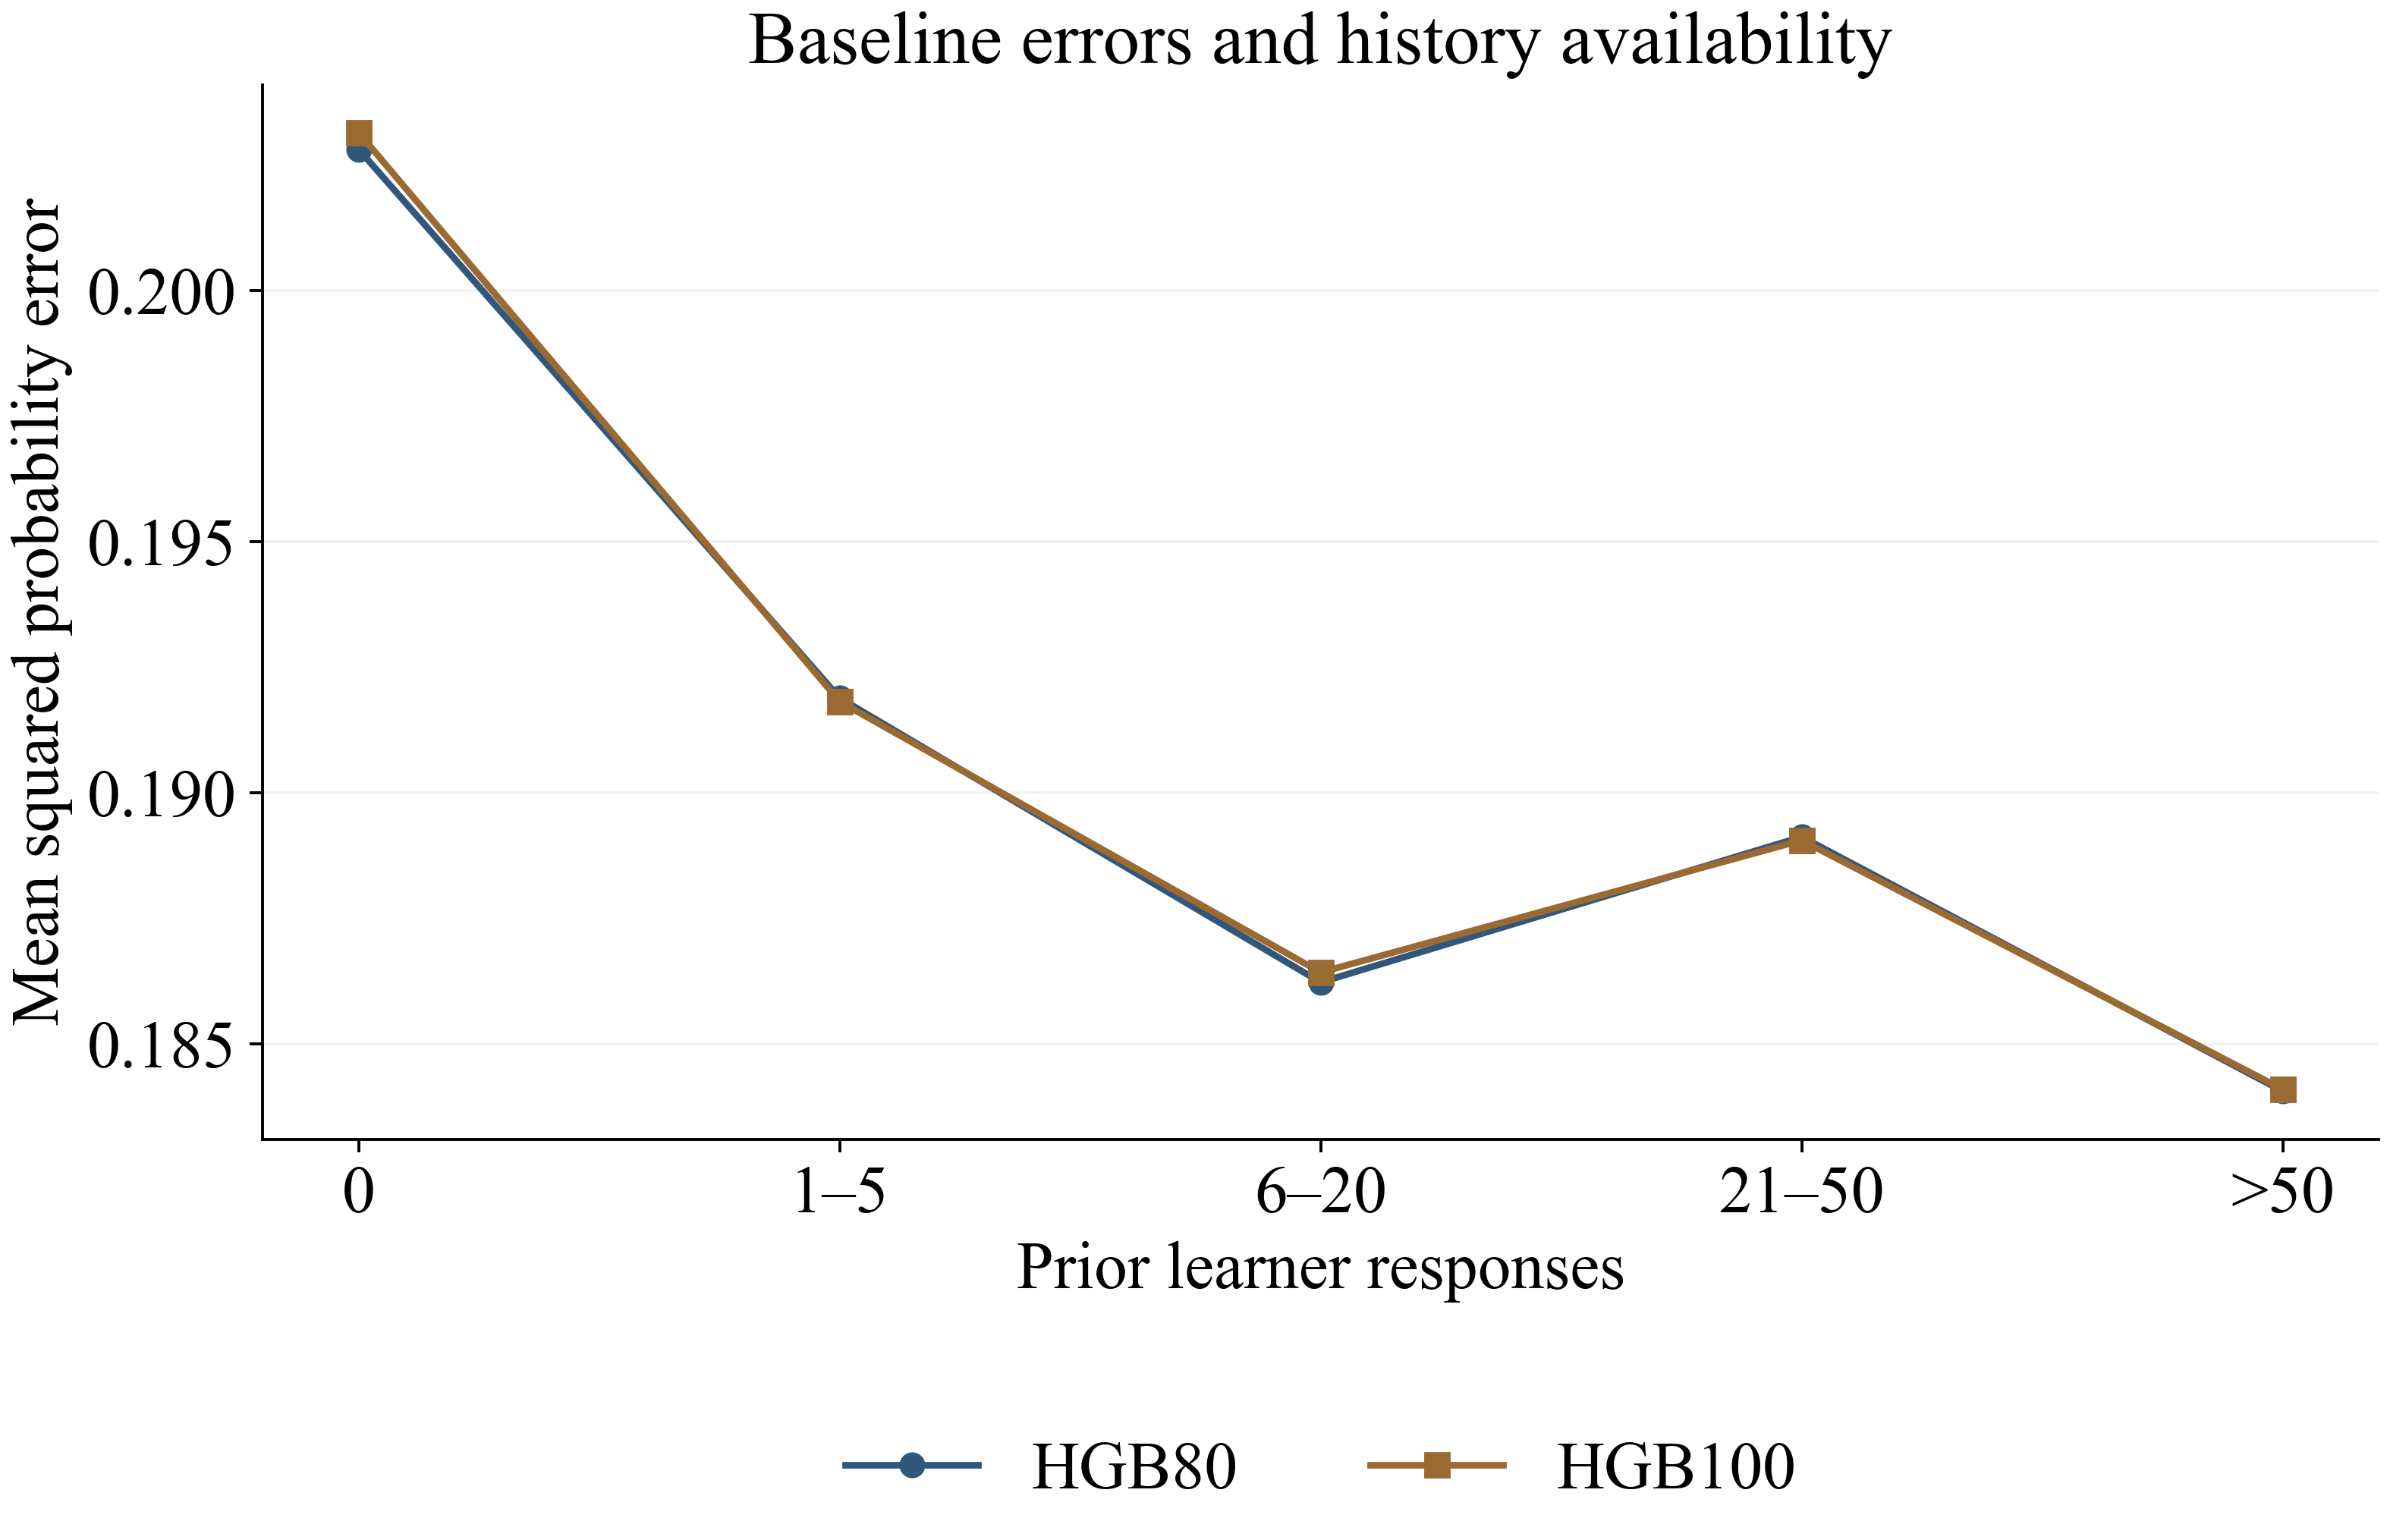

In [20]:
averaged["History"]=pd.cut(averaged.history,[-1,0,5,20,50,np.inf],
    labels=["0","1–5","6–20","21–50",">50"])
averaged["Squared_error"]=(averaged.y-averaged.p)**2
history=averaged.groupby(["model","History"],observed=True).agg(Brier=("Squared_error","mean"),N=("AnswerId","size")).reset_index()
fig,ax=plt.subplots(figsize=(9,5.8),layout="constrained")
for model,color,marker in [("HGB80","#31577A","o"),("HGB100","#9B6A32","s")]:
    g=history[history.model==model]
    ax.plot(g.History.cat.codes,g.Brier,color=color,marker=marker,label=model,linewidth=1.8)
ax.set_xticks(range(5),["0","1–5","6–20","21–50",">50"])
ax.set(xlabel="Prior learner responses",ylabel="Mean squared probability error")
ax.set_title("Baseline errors and history availability")
ax.spines[["top","right"]].set_visible(False);ax.grid(axis="y",alpha=.15)
ax.legend(loc="upper center",bbox_to_anchor=(.5,-.23),ncol=2,frameon=False)
save_canvas(fig,"baseline_history_errors")

The HGB budgets fix 80 or 100 iterations with early stopping disabled; no epoch-loss history was recorded and none is reconstructed artificially. Inner-fold tuning evidence is retained in the model-selection ledger. The chronological outer predictions are out-of-time predictions; inner candidate predictions used to select hyperparameters are not an independent final evaluation.

## Interpretation
The monthly results preserve changes in the target population and available fit history. HGB80 and HGB100 are separate fixed complexity budgets; selecting the strongest observed month or seed would not constitute the prespecified comparison. Paired model differences and conditional uncertainty are evaluated in Notebook 06.